In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Paths
RAW_CSV    = Path("../data/raw/tabular_data/angles_dataset.csv")
CLEAN_CSV  = Path("../data/processed/tabular_data/angles_dataset_clean.csv")

# Load
df = pd.read_csv(RAW_CSV)

print("✅ Dataset loaded.")
print(f"   Shape   : {df.shape}")
print(f"   Columns : {list(df.columns)}")
display(df.head())

✅ Dataset loaded.
   Shape   : (19682, 30)
   Columns : ['video_id', 'frame_number', 'left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle', 'shoulder_z_diff', 'hip_z_diff', 'torso_rotation', 'left_elbow_angle_velocity', 'right_elbow_angle_velocity', 'left_shoulder_angle_velocity', 'right_shoulder_angle_velocity', 'left_hip_angle_velocity', 'right_hip_angle_velocity', 'left_knee_angle_velocity', 'right_knee_angle_velocity', 'left_ankle_angle_velocity', 'right_ankle_angle_velocity', 'shoulder_z_diff_velocity', 'hip_z_diff_velocity', 'torso_rotation_velocity', 'exercise_name', 'exercise_correctness']


,video_id,frame_number,left_elbow_angle,right_elbow_angle,left_shoulder_angle,right_shoulder_angle,left_hip_angle,right_hip_angle,left_knee_angle,right_knee_angle,...,right_hip_angle_velocity,left_knee_angle_velocity,right_knee_angle_velocity,left_ankle_angle_velocity,right_ankle_angle_velocity,shoulder_z_diff_velocity,hip_z_diff_velocity,torso_rotation_velocity,exercise_name,exercise_correctness
0,0,0,123.53,133.99,138.99,150.05,163.41,171.58,168.98,172.80,...,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00,pullup,correct
1,0,1,118.37,131.03,136.90,149.61,164.01,171.91,166.61,173.30,...,9.9,71.1,15.0,153.3,146.1,3.18,2.29,0.89,pullup,correct
2,0,2,109.80,125.55,132.95,145.87,164.80,171.25,166.04,172.26,...,19.8,17.1,31.2,213.0,75.3,2.86,1.71,1.15,pullup,correct
3,0,3,104.63,121.92,129.91,143.21,165.99,171.22,166.99,172.69,...,0.9,28.5,12.9,106.8,1.2,0.87,0.56,0.31,pullup,correct
4,0,4,96.85,110.27,125.62,136.50,166.72,171.62,167.40,172.93,...,12.0,12.3,7.2,53.1,8.1,0.38,0.41,0.03,pullup,correct


In [3]:
print("=" * 60)
print("📋 BASIC INSPECTION")
print("=" * 60)

# 1. Data types
print("\n📌 Column Data Types:")
display(df.dtypes)

# 2. Basic statistics
print("\n📌 Basic Statistics:")
display(df.describe())

# 3. Null values
print("\n📌 Null Values:")
null_counts = df.isnull().sum()
if null_counts.sum() == 0:
    print("✅ No null values found.")
else:
    print("⚠️  Null values detected:")
    display(null_counts[null_counts > 0])

# 4. Duplicate rows
dupe_count = df.duplicated().sum()
if dupe_count == 0:
    print("\n✅ No duplicate rows found.")
else:
    print(f"\n⚠️  {dupe_count} duplicate rows found.")

# 5. Class distributions
print("\n📌 Exercise Distribution:")
display(df["exercise_name"].value_counts())

print("\n📌 Correctness Distribution:")
display(df["exercise_correctness"].value_counts())

print("\n📌 Exercise × Correctness Breakdown:")
display(df.groupby(["exercise_name", "exercise_correctness"]).size().unstack(fill_value=0))

📋 BASIC INSPECTION

📌 Column Data Types:


video_id                           int64
frame_number                       int64
left_elbow_angle                 float64
right_elbow_angle                float64
left_shoulder_angle              float64
right_shoulder_angle             float64
left_hip_angle                   float64
right_hip_angle                  float64
left_knee_angle                  float64
right_knee_angle                 float64
left_ankle_angle                 float64
right_ankle_angle                float64
shoulder_z_diff                  float64
hip_z_diff                       float64
torso_rotation                   float64
left_elbow_angle_velocity        float64
right_elbow_angle_velocity       float64
left_shoulder_angle_velocity     float64
right_shoulder_angle_velocity    float64
left_hip_angle_velocity          float64
right_hip_angle_velocity         float64
left_knee_angle_velocity         float64
right_knee_angle_velocity        float64
left_ankle_angle_velocity        float64
right_ankle_angl


📌 Basic Statistics:


,video_id,frame_number,left_elbow_angle,right_elbow_angle,left_shoulder_angle,right_shoulder_angle,left_hip_angle,right_hip_angle,left_knee_angle,right_knee_angle,...,right_shoulder_angle_velocity,left_hip_angle_velocity,right_hip_angle_velocity,left_knee_angle_velocity,right_knee_angle_velocity,left_ankle_angle_velocity,right_ankle_angle_velocity,shoulder_z_diff_velocity,hip_z_diff_velocity,torso_rotation_velocity
count,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000,...,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000,19682.000000
mean,39.688802,181.338177,107.358135,103.690163,65.923737,64.083454,119.738594,117.755323,132.686187,131.050652,...,104.514897,77.071961,90.292512,94.975174,106.803240,158.391388,157.398930,0.689112,0.268099,0.493721
std,23.689611,157.447358,49.910977,52.880983,49.364421,45.173673,47.871059,50.247072,36.936538,37.826333,...,176.005855,163.300759,252.508612,224.005092,275.075994,282.580580,281.897192,0.882535,0.442062,0.588980
min,0.000000,0.000000,0.090000,0.060000,0.000000,0.000000,0.040000,0.080000,0.190000,0.040000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,62.000000,64.720000,58.060000,27.060000,29.135000,77.240000,73.332500,106.270000,101.622500,...,17.400000,13.800000,15.000000,16.200000,16.812500,26.100000,28.437500,0.140000,0.030000,0.110000
50%,42.000000,136.000000,114.805000,109.725000,53.020000,53.155000,133.655000,129.265000,139.470000,133.385000,...,49.250000,37.830000,39.900000,43.500000,44.400000,69.750000,72.720000,0.390000,0.110000,0.295000
75%,62.000000,255.000000,152.532500,154.137500,96.792500,96.547500,163.877500,165.660000,165.330000,165.660000,...,125.995000,89.480000,87.390000,99.300000,100.580000,175.040000,175.895000,0.890000,0.320000,0.660000
max,78.000000,718.000000,180.000000,180.000000,179.960000,179.990000,179.990000,180.000000,180.000000,180.000000,...,4153.610000,5111.930000,4998.600000,4718.100000,5092.200000,5030.400000,5162.730000,17.780000,9.600000,9.180000



📌 Null Values:
✅ No null values found.

✅ No duplicate rows found.

📌 Exercise Distribution:


exercise_name
russian_twist    6246
pullup           4610
pushup           4427
squat            4399
Name: count, dtype: int64


📌 Correctness Distribution:


exercise_correctness
correct      10190
incorrect     9492
Name: count, dtype: int64


📌 Exercise × Correctness Breakdown:


exercise_correctness,correct,incorrect
exercise_name,,
pullup,2509,2101
pushup,2295,2132
russian_twist,3116,3130
squat,2270,2129


In [4]:
print("=" * 60)
print("🧹 ANGLE RANGE VALIDATION & CLEANING")
print("=" * 60)

# Separate angle and velocity columns
angle_cols    = [col for col in df.columns if "angle" in col and "velocity" not in col]
velocity_cols = [col for col in df.columns if "velocity" in col]

print(f"\n📌 Angle columns    ({len(angle_cols)})  : {angle_cols}")
print(f"📌 Velocity columns ({len(velocity_cols)}): {velocity_cols}")

# --- 1. Check angles outside [0, 180] ---
print("\n📌 Frames with at least one angle outside [0°, 180°]:")
invalid_angle_mask = df[angle_cols].apply(lambda col: (col < 0) | (col > 180)).any(axis=1)
invalid_angle_count = invalid_angle_mask.sum()

if invalid_angle_count == 0:
    print("✅ All angles are within [0°, 180°].")
else:
    print(f"⚠️  {invalid_angle_count} frames have out-of-range angles — will be removed.")
    display(df[invalid_angle_mask][angle_cols].describe())

# --- 2. Check torso rotation features (no fixed range, just sanity check) ---
print("\n📌 Torso rotation features range:")
torso_cols = ["shoulder_z_diff", "hip_z_diff", "torso_rotation"]
display(df[torso_cols].describe())

# --- 3. Check for unrealistic velocities (e.g. > 3000 °/s is almost certainly noise) ---
VELOCITY_THRESHOLD = 3000  # degrees per second
print(f"\n📌 Frames with any velocity > {VELOCITY_THRESHOLD}°/s (likely noise):")
invalid_velocity_mask = df[velocity_cols].apply(lambda col: col > VELOCITY_THRESHOLD).any(axis=1)
invalid_velocity_count = invalid_velocity_mask.sum()

if invalid_velocity_count == 0:
    print(f"✅ No unrealistic velocities found.")
else:
    print(f"⚠️  {invalid_velocity_count} frames have unrealistic velocities — will be removed.")

# --- 4. Remove all invalid frames ---
invalid_mask = invalid_angle_mask | invalid_velocity_mask
df_clean = df[~invalid_mask].reset_index(drop=True)

print(f"\n🗑️  Removed : {invalid_mask.sum()} invalid frames")
print(f"✅ Remaining: {len(df_clean)} frames")

# --- 5. Drop duplicate rows ---
before = len(df_clean)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
after = len(df_clean)
print(f"\n🗑️  Duplicate rows removed: {before - after}")
print(f"✅ Final shape: {df_clean.shape}")

🧹 ANGLE RANGE VALIDATION & CLEANING

📌 Angle columns    (10)  : ['left_elbow_angle', 'right_elbow_angle', 'left_shoulder_angle', 'right_shoulder_angle', 'left_hip_angle', 'right_hip_angle', 'left_knee_angle', 'right_knee_angle', 'left_ankle_angle', 'right_ankle_angle']
📌 Velocity columns (13): ['left_elbow_angle_velocity', 'right_elbow_angle_velocity', 'left_shoulder_angle_velocity', 'right_shoulder_angle_velocity', 'left_hip_angle_velocity', 'right_hip_angle_velocity', 'left_knee_angle_velocity', 'right_knee_angle_velocity', 'left_ankle_angle_velocity', 'right_ankle_angle_velocity', 'shoulder_z_diff_velocity', 'hip_z_diff_velocity', 'torso_rotation_velocity']

📌 Frames with at least one angle outside [0°, 180°]:
✅ All angles are within [0°, 180°].

📌 Torso rotation features range:


,shoulder_z_diff,hip_z_diff,torso_rotation
count,19682.000000,19682.000000,19682.000000
mean,-0.096062,-0.072432,-0.023631
std,0.401909,0.270088,0.145670
min,-0.912100,-0.593700,-0.455700
25%,-0.438700,-0.286200,-0.150500
50%,-0.113650,-0.138100,-0.030100
75%,0.145175,0.134325,0.087075
max,0.948100,0.620500,0.372700



📌 Frames with any velocity > 3000°/s (likely noise):
⚠️  333 frames have unrealistic velocities — will be removed.

🗑️  Removed : 333 invalid frames
✅ Remaining: 19349 frames

🗑️  Duplicate rows removed: 0
✅ Final shape: (19349, 30)


📊 VISUALIZING CLEANED DISTRIBUTIONS


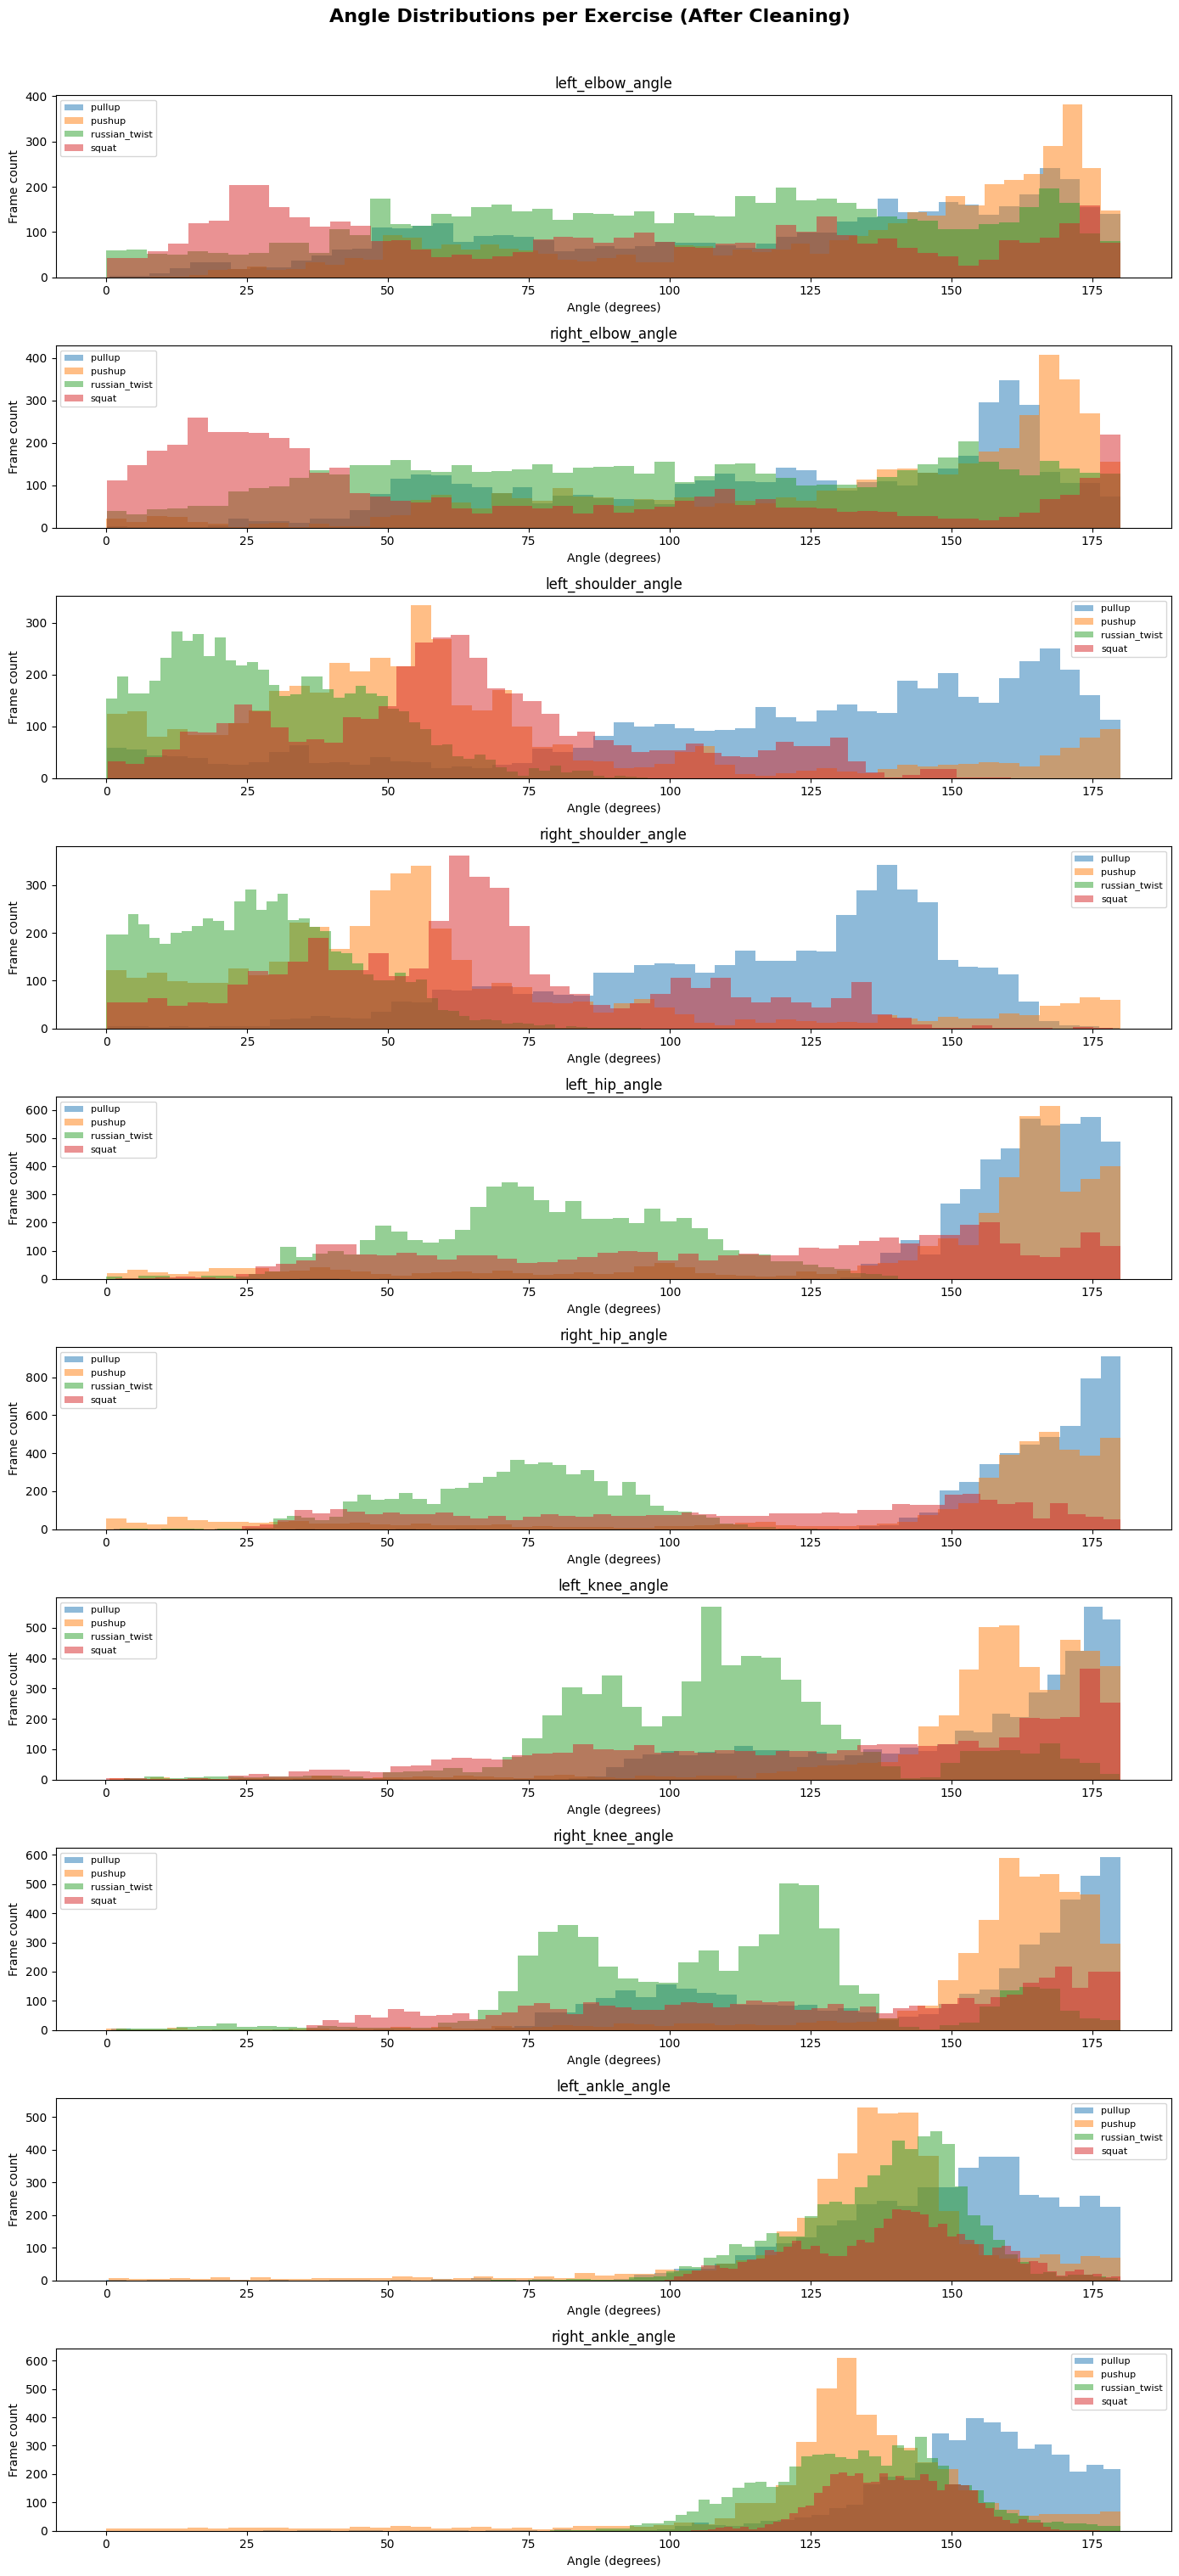

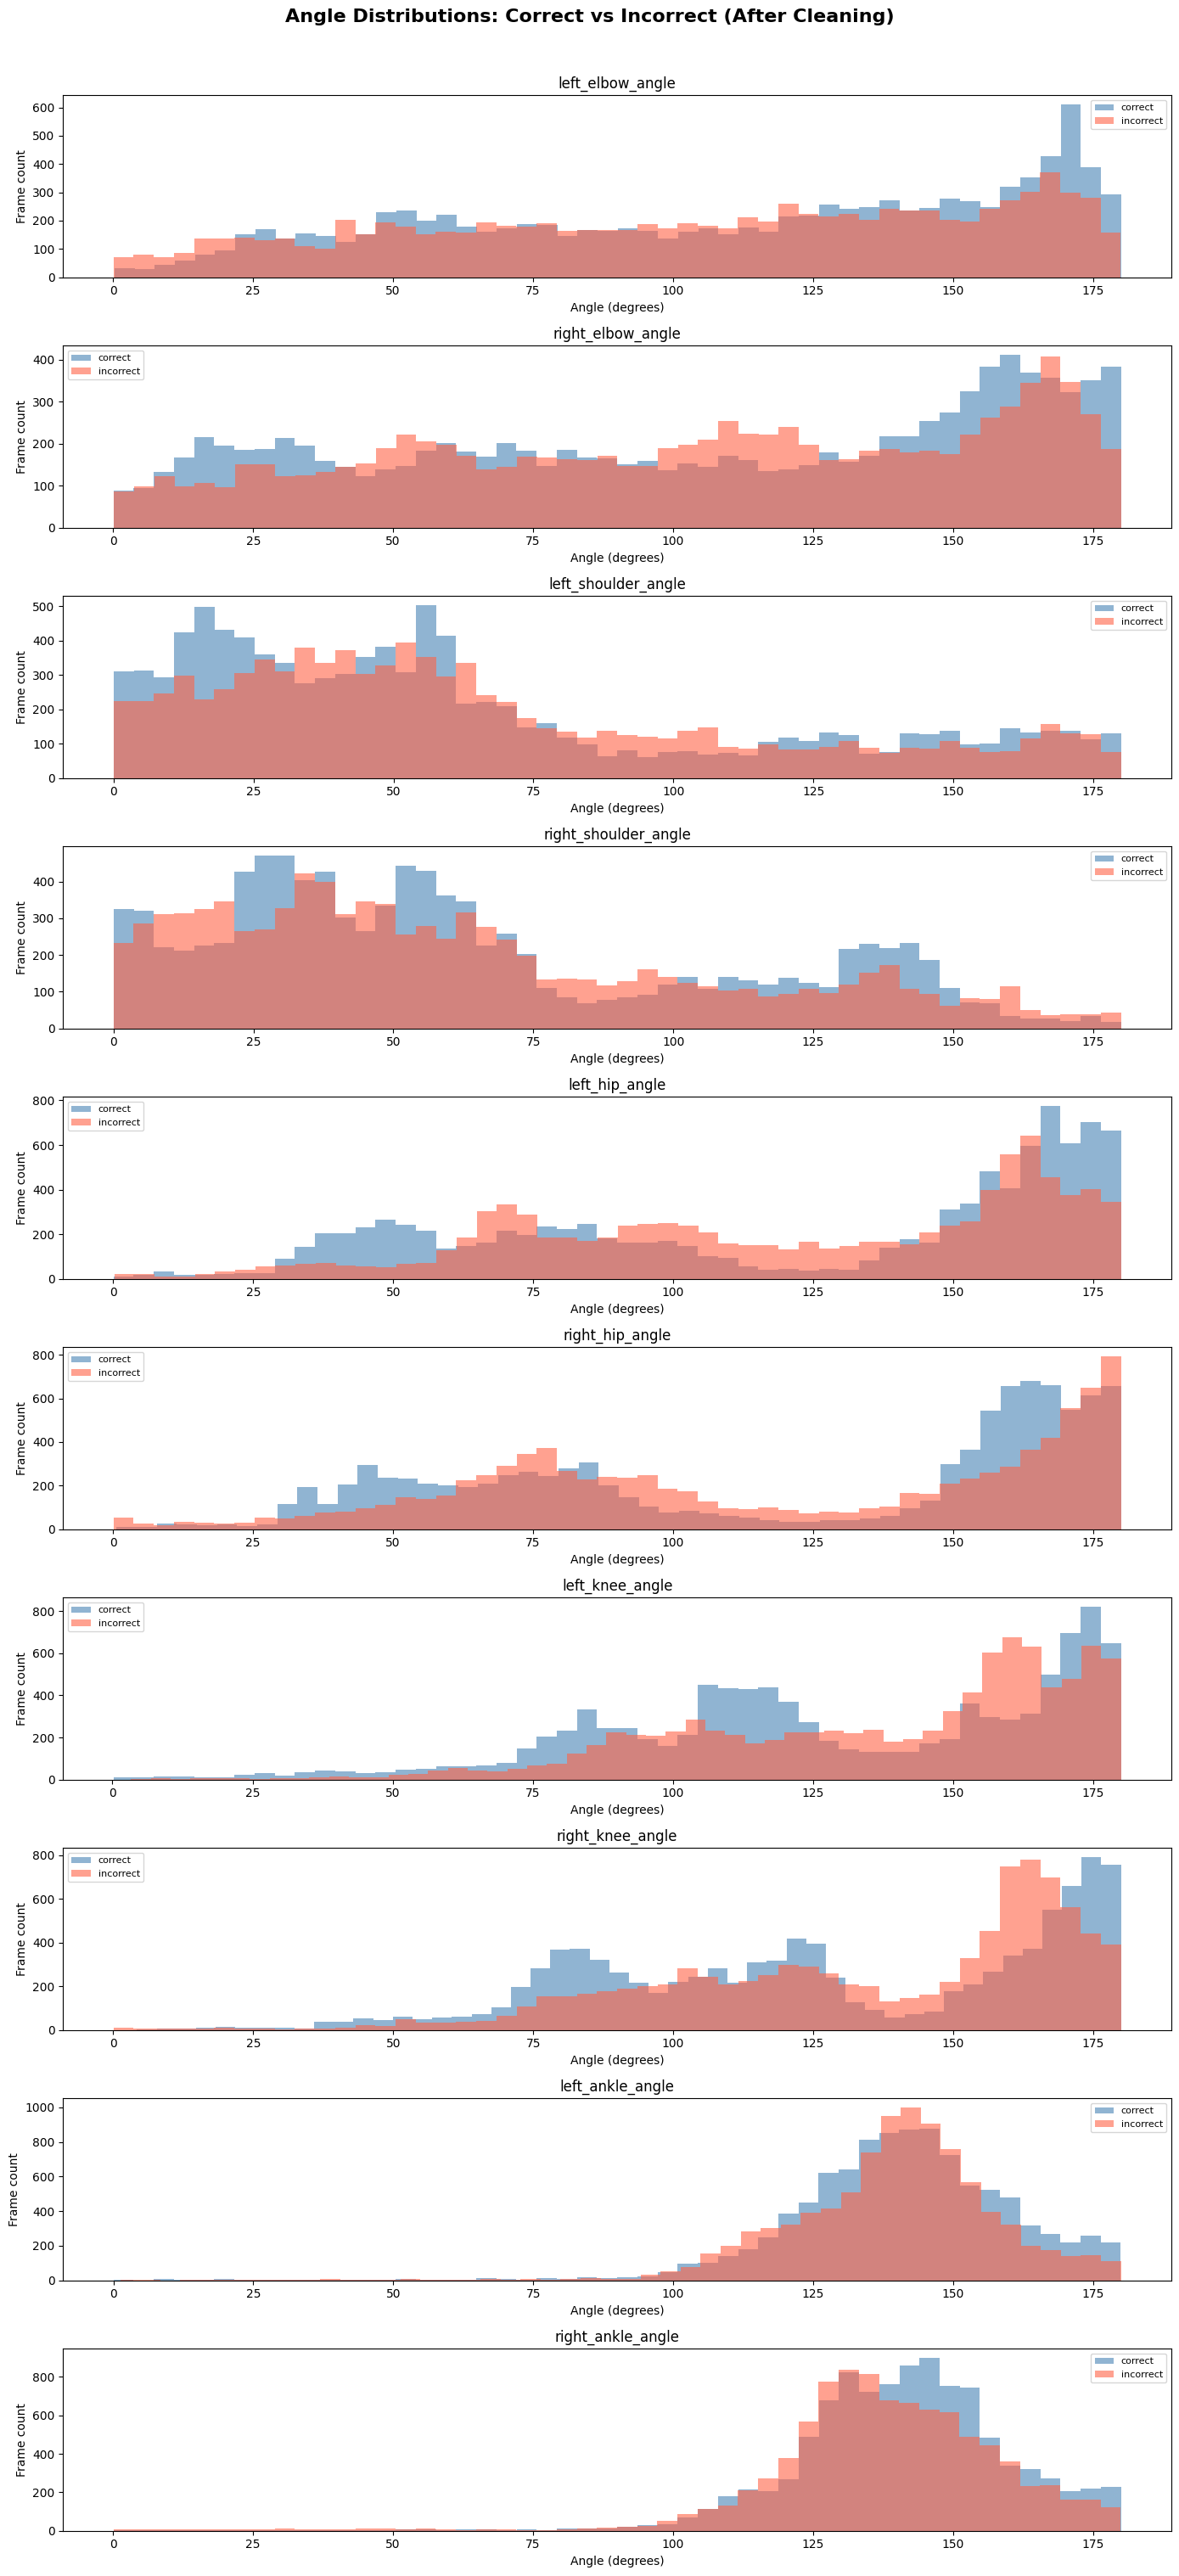

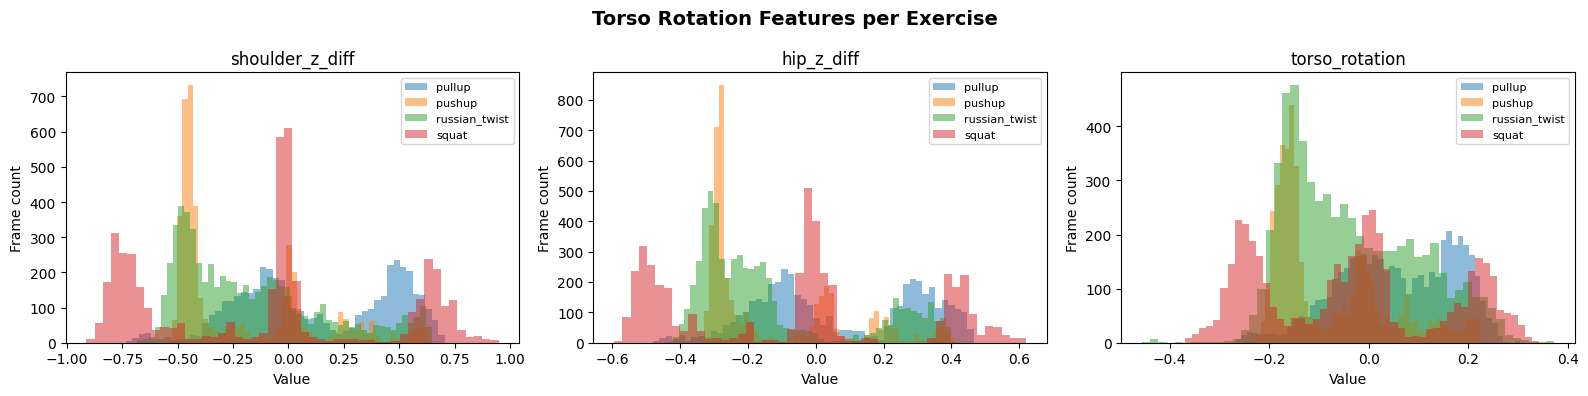

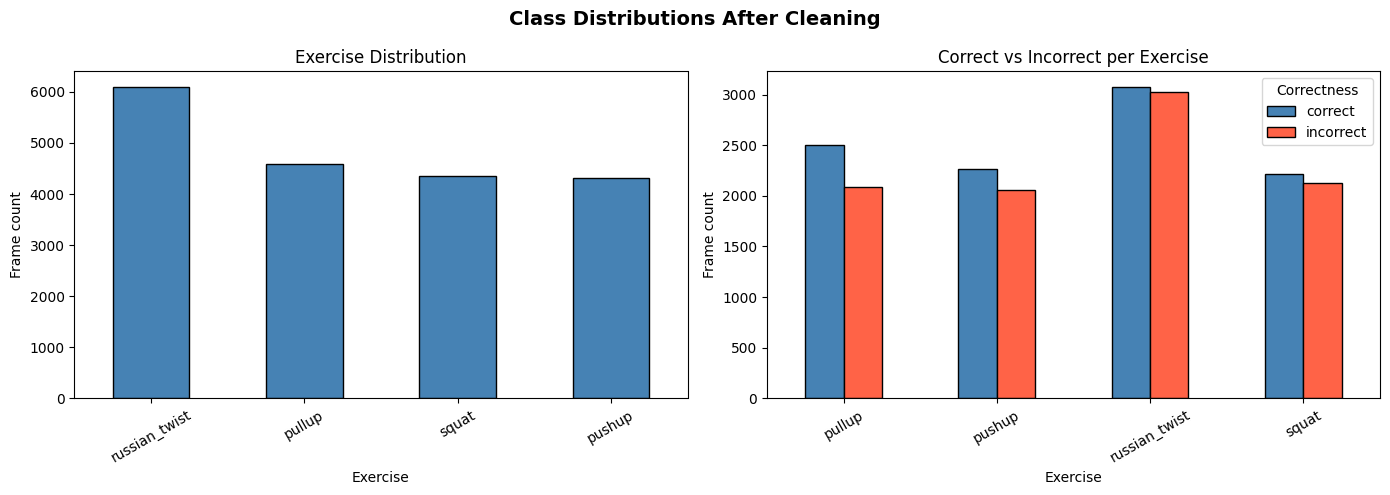

In [5]:
print("=" * 60)
print("📊 VISUALIZING CLEANED DISTRIBUTIONS")
print("=" * 60)

# --- 1. Angle distributions per exercise ---
fig, axes = plt.subplots(len(angle_cols), 1, figsize=(14, len(angle_cols) * 3))
fig.suptitle("Angle Distributions per Exercise (After Cleaning)", fontsize=16, fontweight="bold", y=1.01)

for ax, col in zip(axes, angle_cols):
    for exercise in df_clean["exercise_name"].unique():
        subset = df_clean[df_clean["exercise_name"] == exercise][col]
        ax.hist(subset, bins=50, alpha=0.5, label=exercise)
    ax.set_title(col)
    ax.set_xlabel("Angle (degrees)")
    ax.set_ylabel("Frame count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- 2. Correct vs Incorrect angle distributions ---
fig, axes = plt.subplots(len(angle_cols), 1, figsize=(14, len(angle_cols) * 3))
fig.suptitle("Angle Distributions: Correct vs Incorrect (After Cleaning)", fontsize=16, fontweight="bold", y=1.01)

for ax, col in zip(axes, angle_cols):
    for correctness, color in zip(["correct", "incorrect"], ["steelblue", "tomato"]):
        subset = df_clean[df_clean["exercise_correctness"] == correctness][col]
        ax.hist(subset, bins=50, alpha=0.6, label=correctness, color=color)
    ax.set_title(col)
    ax.set_xlabel("Angle (degrees)")
    ax.set_ylabel("Frame count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- 3. Torso rotation distribution per exercise ---
fig, axes = plt.subplots(1, len(torso_cols), figsize=(16, 4))
fig.suptitle("Torso Rotation Features per Exercise", fontsize=14, fontweight="bold")

for ax, col in zip(axes, torso_cols):
    for exercise in df_clean["exercise_name"].unique():
        subset = df_clean[df_clean["exercise_name"] == exercise][col]
        ax.hist(subset, bins=50, alpha=0.5, label=exercise)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Frame count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- 4. Class distribution after cleaning ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Class Distributions After Cleaning", fontsize=14, fontweight="bold")

df_clean["exercise_name"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title("Exercise Distribution")
axes[0].set_xlabel("Exercise")
axes[0].set_ylabel("Frame count")
axes[0].tick_params(axis="x", rotation=30)

df_clean.groupby(["exercise_name", "exercise_correctness"]).size().unstack().plot(
    kind="bar", ax=axes[1], color=["steelblue", "tomato"], edgecolor="black"
)
axes[1].set_title("Correct vs Incorrect per Exercise")
axes[1].set_xlabel("Exercise")
axes[1].set_ylabel("Frame count")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(title="Correctness")

plt.tight_layout()
plt.show()

In [6]:
print("=" * 60)
print("🔤 ENCODING LABELS")
print("=" * 60)

# --- 1. Encode exercise_name ---
exercise_mapping = {name: idx for idx, name in enumerate(sorted(df_clean["exercise_name"].unique()))}
correctness_mapping = {"correct": 1, "incorrect": 0}

print(f"\n📌 Exercise mapping    : {exercise_mapping}")
print(f"📌 Correctness mapping : {correctness_mapping}")

df_clean["exercise_name_encoded"]        = df_clean["exercise_name"].map(exercise_mapping)
df_clean["exercise_correctness_encoded"] = df_clean["exercise_correctness"].map(correctness_mapping)

# --- 2. Verify encoding ---
print("\n📌 Encoding verification:")
display(df_clean[["exercise_name", "exercise_name_encoded",
                   "exercise_correctness", "exercise_correctness_encoded"]].drop_duplicates().sort_values("exercise_name_encoded"))

# --- 3. Verify no nulls were introduced by encoding ---
encoding_nulls = df_clean[["exercise_name_encoded", "exercise_correctness_encoded"]].isnull().sum()
if encoding_nulls.sum() == 0:
    print("\n✅ Encoding successful, no nulls introduced.")
else:
    print("\n⚠️  Nulls introduced during encoding:")
    display(encoding_nulls[encoding_nulls > 0])

# --- 4. Verify all columns are now numerical (except original label columns) ---
non_numeric_cols = df_clean.drop(columns=["exercise_name", "exercise_correctness"]).select_dtypes(exclude=[np.number]).columns.tolist()
if not non_numeric_cols:
    print("✅ All columns (except original labels) are numerical.")
else:
    print(f"⚠️  Non-numerical columns detected: {non_numeric_cols}")

# --- 5. Final column overview ---
print(f"\n📌 Final columns ({len(df_clean.columns)}):")
display(df_clean.dtypes)

# --- 6. Save ---
df_clean.to_csv(CLEAN_CSV, index=False)
print(f"\n✅ Cleaned dataset saved to: {CLEAN_CSV}")
print(f"   Shape: {df_clean.shape}")

🔤 ENCODING LABELS

📌 Exercise mapping    : {'pullup': 0, 'pushup': 1, 'russian_twist': 2, 'squat': 3}
📌 Correctness mapping : {'correct': 1, 'incorrect': 0}

📌 Encoding verification:


,exercise_name,exercise_name_encoded,exercise_correctness,exercise_correctness_encoded
0,pullup,0,correct,1
2504,pullup,0,incorrect,0
4589,pushup,1,correct,1
6851,pushup,1,incorrect,0
8907,russian_twist,2,correct,1
11983,russian_twist,2,incorrect,0
15004,squat,3,correct,1
17224,squat,3,incorrect,0



✅ Encoding successful, no nulls introduced.
✅ All columns (except original labels) are numerical.

📌 Final columns (32):


video_id                           int64
frame_number                       int64
left_elbow_angle                 float64
right_elbow_angle                float64
left_shoulder_angle              float64
right_shoulder_angle             float64
left_hip_angle                   float64
right_hip_angle                  float64
left_knee_angle                  float64
right_knee_angle                 float64
left_ankle_angle                 float64
right_ankle_angle                float64
shoulder_z_diff                  float64
hip_z_diff                       float64
torso_rotation                   float64
left_elbow_angle_velocity        float64
right_elbow_angle_velocity       float64
left_shoulder_angle_velocity     float64
right_shoulder_angle_velocity    float64
left_hip_angle_velocity          float64
right_hip_angle_velocity         float64
left_knee_angle_velocity         float64
right_knee_angle_velocity        float64
left_ankle_angle_velocity        float64
right_ankle_angl


✅ Cleaned dataset saved to: ..\data\processed\tabular_data\angles_dataset_clean.csv
   Shape: (19349, 32)
